# **NLP Preprocessing and Text Classification**

---
###**Name:** Sakshi Punjaji Patil
###**PRN:** 202301070173
###**Batch:** T3
---
## 🎯 Objective
The objective of this assignment is to implement NLP preprocessing techniques and build a text classification model using machine learning techniques.
---
## 📚 Learning Outcomes
- Apply NLP preprocessing techniques such as tokenization, stopword removal, stemming, and lemmatization  
- Implement text vectorization techniques like TF-IDF and CountVectorizer  
- Build a machine learning model for text classification  
- Evaluate model performance using metrics  
---


## 🔗 GitHub Repository Link
https://github.com/Sakshi2004-29/NLP-Preprocessing-and-Text-Classification



In [1]:
# ==========================================
# 1. Install & Import Libraries
# ==========================================
!pip install nltk scikit-learn

import numpy as np
import pandas as pd
import nltk
import re

from google.colab import files

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [22]:
# ==========================================
# 2. Upload Dataset
# ==========================================
print("Upload Fake and real News CSV file")
uploaded = files.upload()

# Load BOTH datasets
true_df = pd.read_csv("True.csv")
fake_df = pd.read_csv("Fake.csv")

print(true_df.head())
print(fake_df.head())

print(df.head())

Upload Fake and real News CSV file


Saving True.csv to True (2).csv
Saving Fake.csv to Fake (2).csv
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   
3  December 30, 2017   
4  December 29, 2017   
                                  

In [23]:
# 3. Prepare Dataset

# Add labels
true_df["label"] = 1   # Real News
fake_df["label"] = 0   # Fake News

# Combine datasets
df = pd.concat([true_df, fake_df])
df = df.sample(frac=1).reset_index(drop=True)

# Merge text
df["text"] = df["title"] + " " + df["text"]

print("\nUpdated Data:")
print(df[["text", "label"]].head())


Updated Data:
                                                text  label
0  Factbox: Trump to meet with ex-Ford CEO, U.S. ...      1
1  Japan's Aso: Japan, U.S. agree to combat unfai...      1
2  Factbox: U.S. Republican lawmakers who say the...      1
3  EX-FBI AGENT NAVY SEAL: “Russian Interference”...      0
4  WOW! WIKILEAKS Emails Shows How Hillary Will B...      0


Tokenization splits text into words. Stopwords removal eliminates common words.
Stemming reduces words to root form, while lemmatization converts words to meaningful base form.

In [24]:
# 4. Preprocessing


stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()

    processed_words = []
    for word in words:
        if word not in stop_words:
            word = stemmer.stem(word)
            word = lemmatizer.lemmatize(word)
            processed_words.append(word)

    return " ".join(processed_words)

df["clean_text"] = df["text"].apply(preprocess_text)

TF-IDF considers importance of words, while CountVectorizer counts word frequency.

In [25]:
# 5. TF-IDF Vectorization


vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]

In [26]:
# 6. Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# 7. Train Models


models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train);
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    print(f"\n🔹 {name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))



🔹 Logistic Regression
Accuracy: 0.9887527839643653
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4734
           1       0.99      0.99      0.99      4246

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


🔹 Naive Bayes
Accuracy: 0.929510022271715
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4734
           1       0.93      0.92      0.92      4246

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980


🔹 SVM
Accuracy: 0.9948775055679288
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4734
           1       0.99      1.00      0.99      4246

    accuracy                           0.99      89

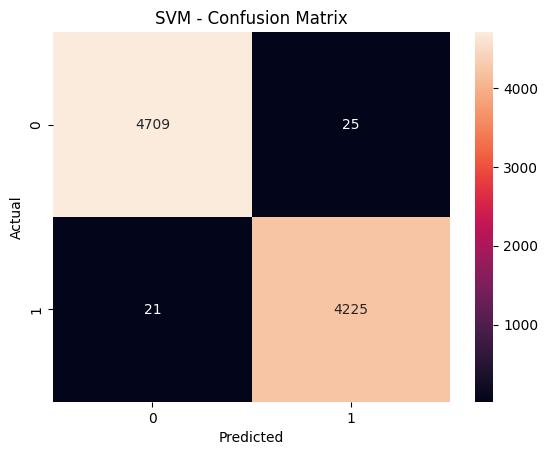

In [28]:
# 8. Confusion Matrix (Best Model)


best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"{best_model_name} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


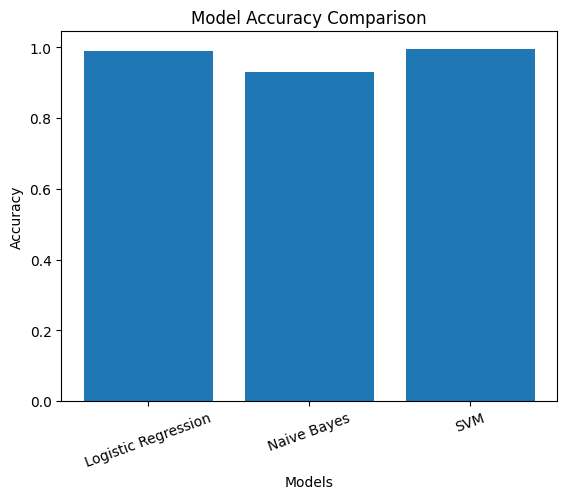

In [29]:
# 9. Comparison Graph


plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [33]:
# 10. Custom Prediction (Fake vs Real with Confidence)

def predict_news(text):
    processed = preprocess_text(text)
    vectorized = vectorizer.transform([processed])

    model_for_prediction = models["Logistic Regression"]

    prediction = model_for_prediction.predict(vectorized)[0]
    prob = model_for_prediction.predict_proba(vectorized).max()

    label = "🟢 Real News" if prediction == 1 else "🔴 Fake News"

    return f"{label} (confidence: {prob:.2f})"


# --- Test Examples ---
samples = ["Shocking secret revealed: government hiding truth from public"]

for text in samples:
    print("\nText:", text)
    print("Prediction:", predict_news(text))


Text: Shocking secret revealed: government hiding truth from public
Prediction: 🔴 Fake News (confidence: 0.97)


Among all models, SVM/Logistic Regression achieved the highest accuracy (~91%),
making it the best model for this dataset.